In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("./../data/Salaries.csv")

In [12]:
df.describe()

,Id,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Status
count,148654.000000,148045.000000,148650.000000,148650.000000,112491.000000,148654.000000,148654.000000,148654.000000,0.0,0.0
mean,74327.500000,66325.448840,5066.059886,3648.767297,25007.893151,74768.321972,93692.554811,2012.522643,NaN,NaN
std,42912.857795,42764.635495,11454.380559,8056.601866,15402.215858,50517.005274,62793.533483,1.117538,NaN,NaN
min,1.000000,-166.010000,-0.010000,-7058.590000,-33.890000,-618.130000,-618.130000,2011.000000,NaN,NaN
25%,37164.250000,33588.200000,0.000000,0.000000,11535.395000,36168.995000,44065.650000,2012.000000,NaN,NaN
50%,74327.500000,65007.450000,0.000000,811.270000,28628.620000,71426.610000,92404.090000,2013.000000,NaN,NaN
75%,111490.750000,94691.050000,4658.175000,4236.065000,35566.855000,105839.135000,132876.450000,2014.000000,NaN,NaN
max,148654.000000,319275.010000,245131.880000,400184.250000,96570.660000,567595.430000,567595.430000,2014.000000,NaN,NaN


### Scatter Plot

<Axes: xlabel='BasePay', ylabel='TotalPay'>

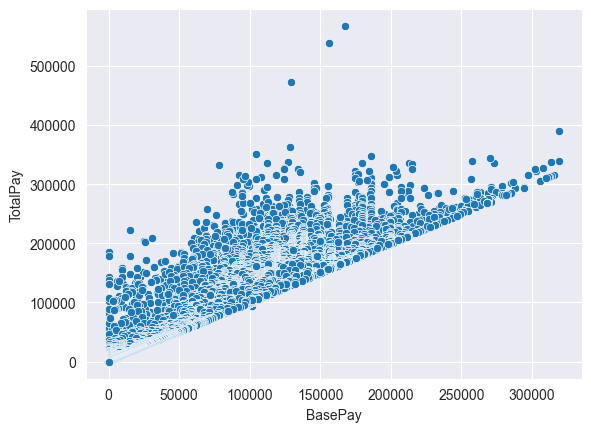

In [13]:
sns.scatterplot(x='BasePay',y='TotalPay',data=df)

### Connecting to Figure in Matplotlib


**Note how matplotlib is still connected to seaborn underneath (even without importing matplotlib.pyplot), since seaborn itself is directly making a Figure call with matplotlib. We can import matplotlib.pyplot and make calls to directly effect the seaborn figure.**

<Axes: xlabel='BasePay', ylabel='TotalPay'>

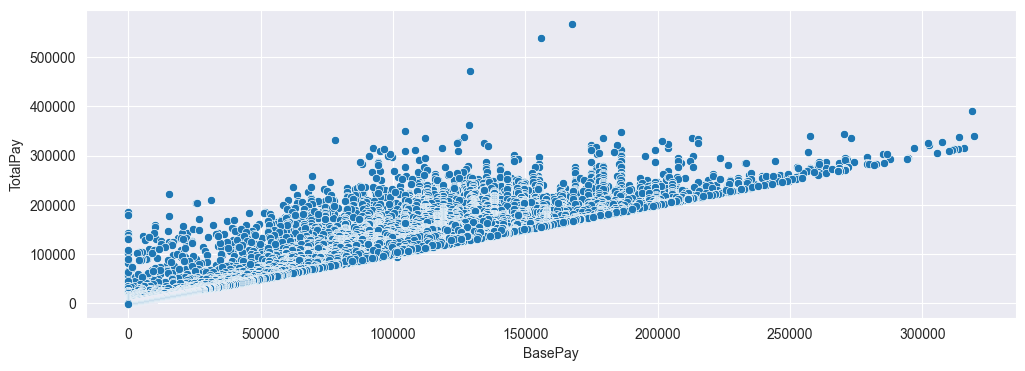

In [15]:
plt.figure(figsize=(12,4))
sns.scatterplot(x='BasePay',y='TotalPay',data=df)

### Seaborn Parameters

The hue and palette parameters are commonly available around many plot calls in seaborn.

#### hue

Color points based off a categorical feature in the DataFrame

<Axes: xlabel='BasePay', ylabel='TotalPay'>

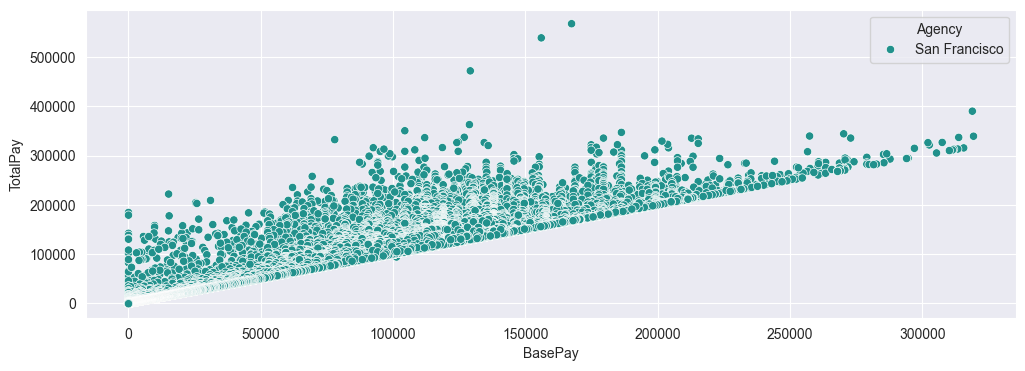

In [25]:
plt.figure(figsize=(12,4))
sns.scatterplot(x='BasePay',y='TotalPay',data=df,hue='Agency',palette='viridis')

**Choosing a palette from Matplotlib's cmap: https://matplotlib.org/tutorials/colors/colormaps.html**

### Scatterplot  Parameters

These parameters are more specific to the scatterplot() call

#### size

Allows you to size based on another column

<Axes: xlabel='BasePay', ylabel='TotalPay'>

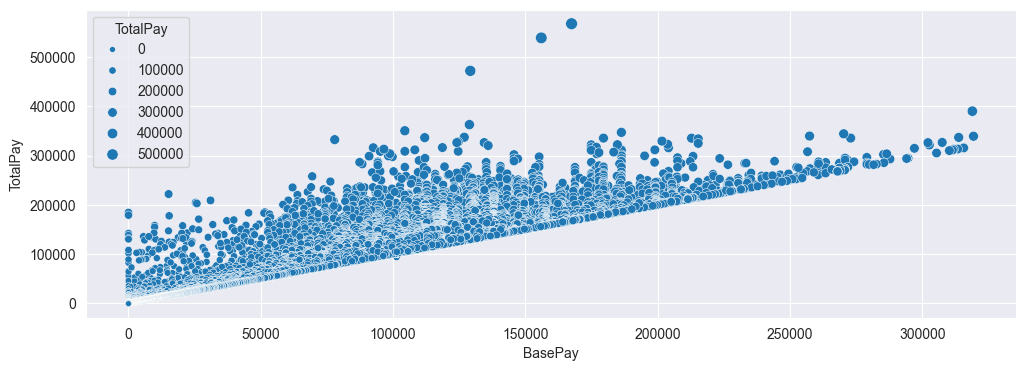

In [27]:
plt.figure(figsize=(12,4))
sns.scatterplot(x='BasePay',y='TotalPay',data=df,size='TotalPay')

**Use *s=* if you want to change the marker size to be some uniform integer value**

<Axes: xlabel='BasePay', ylabel='TotalPay'>

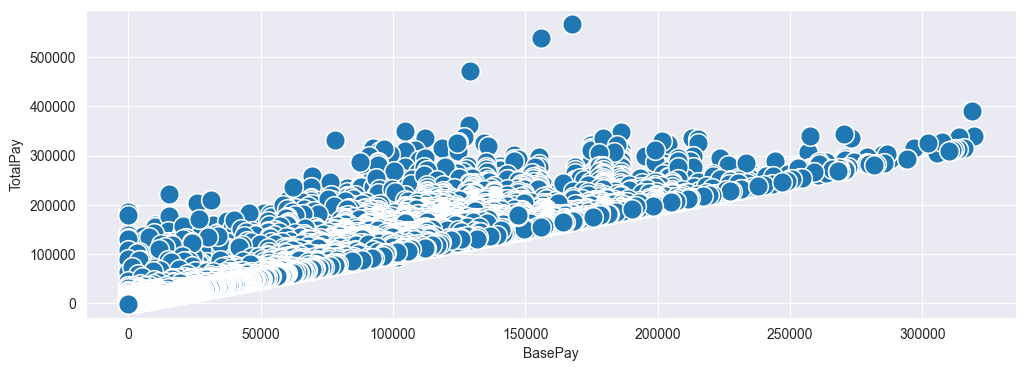

In [28]:
plt.figure(figsize=(12,4))
sns.scatterplot(x='BasePay',y='TotalPay',data=df,s=200)

<Axes: xlabel='BasePay', ylabel='TotalPay'>

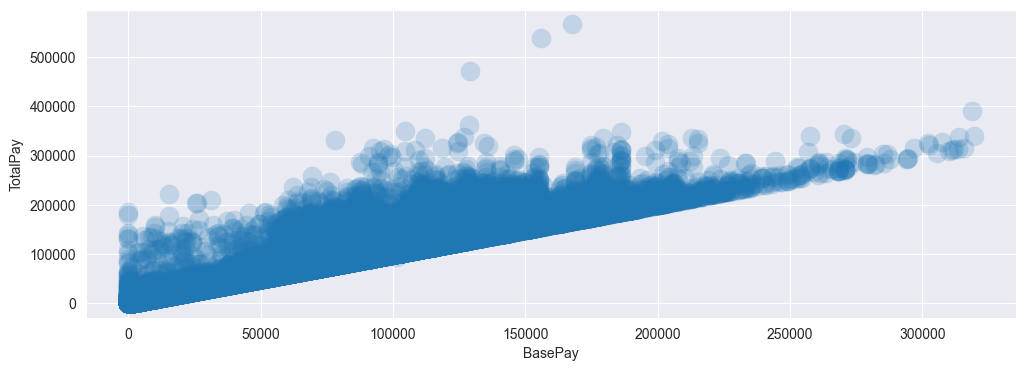

In [29]:
plt.figure(figsize=(12,4))
sns.scatterplot(x='BasePay',y='TotalPay',data=df,s=200,linewidth=0,alpha=0.2)

| Parametre      | Açıklama                                                                     |
| -------------- | ---------------------------------------------------------------------------- |
| `x='BasePay'`  | X ekseninde gösterilecek değişken (`BasePay`)                                |
| `y='TotalPay'` | Y ekseninde gösterilecek değişken (`TotalPay`)                               |
| `data=df`      | Bu sütunların alındığı veri seti (`df`)                                      |
| `s=200`        | Noktaların boyutu (varsayılan genelde 40’tır) → 200 büyük demektir           |
| `linewidth=0`  | Nokta kenar çizgilerini kaldırır (daha yumuşak görünür)                      |
| `alpha=0.2`    | Şeffaflık değeri (0: tamamen saydam, 1: tamamen opak) → 0.2 = %20 görünürlük |


In [35]:
df_s = pd.read_csv("./../data/dm_office_sales.csv")

### style

Automatically choose styles based on another categorical feature in the dataset. Optionally use the **markers=** parameter to pass a list of marker choices based off matplotlib, for example: ['*','+','o']

<Axes: xlabel='salary', ylabel='sales'>

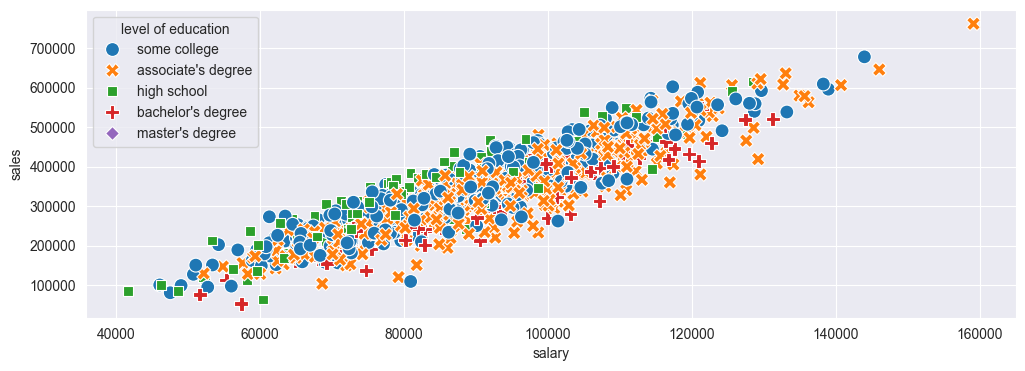

In [37]:
plt.figure(figsize=(12,4))
# sns.scatterplot(x='BasePay',y='TotalPay',data=df_s,style='TotalPay')
sns.scatterplot(x='salary',y='sales',data=df_s,style='level of education',hue='level of education',s=100)

# plt.savefig('example_scatter.jpg')

### Distributions

There are many ways to display the distributions of a feature. In this notebook we explore 3 related plots for displaying a distribution,  the rugplot , the distplot (histogram), and kdeplot.

### displot() and histplot()

The displot is a plot type that can show you the distribution of a single feature. It is a histogram with the option of adding a "KDE" plot (Kernel Density Estimation) on top of the histogram. Let's explore its use cases and syntax.

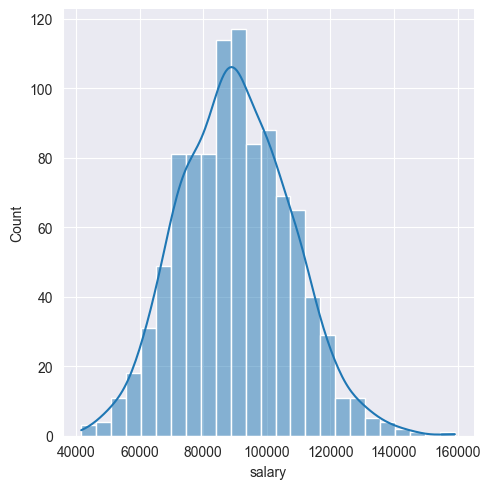

In [38]:
sns.displot(data=df_s,x='salary',kde=True)

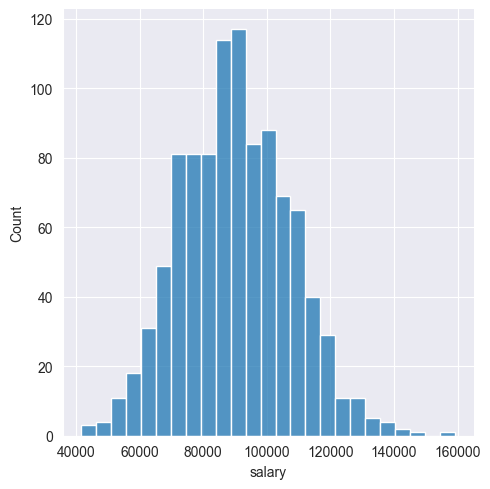

In [39]:
sns.displot(data=df_s,x='salary')

<Axes: xlabel='salary', ylabel='Count'>

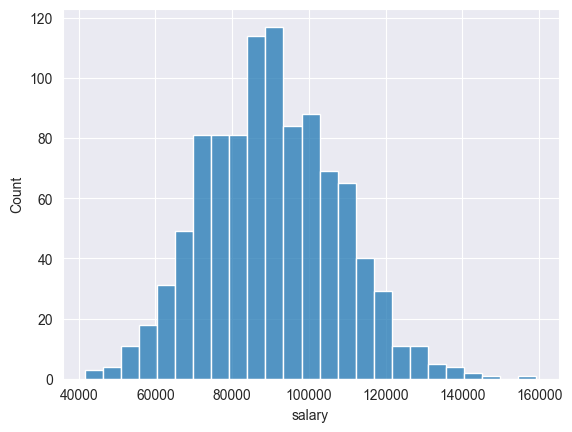

In [40]:
sns.histplot(data=df_s,x='salary')

| Özellik                           | 🟦 `sns.histplot()`                          | 🟩 `sns.displot()`                                          |
| --------------------------------- | -------------------------------------------- | ----------------------------------------------------------- |
| **Türü**                          | Axes-level (tek grafik)                      | Figure-level (çoklu grafik oluşturabilir)                   |
| **Figure oluşturma**              | Manuel (`plt.figure()` ile sen oluşturursun) | Otomatik olarak kendi oluşturur                             |
| **Kullanım amacı**                | Tek bir değişkenin dağılımını göstermek      | Bir veya birden fazla kategorinin dağılımını karşılaştırmak |
| **Kullanım kolaylığı**            | Daha basit ve hızlı                          | Daha esnek ama biraz daha karmaşık                          |
| **Alt grafik (subplots)**         | Yok                                          | Var (`col=`, `row=`, `hue=` ile çoklu grafik)               |
| **Kullanılan temel fonksiyonlar** | Histogram veya KDE                           | İçinde `histplot` / `kdeplot` kullanır                      |
| **Hız / Performans**              | Daha hızlı (tek eksen üzerinde çalışır)      | Daha yavaş (grid mantığıyla çalışır)                        |
| **Görsel kontrol**                | `plt` ile doğrudan kontrol edebilirsin       | Kendi figür yapısı üzerinden kontrol edilir                 |
| **Tipik kullanım örneği**         | `sns.histplot(df['Age'], kde=True)`          | `sns.displot(df, x='Age', hue='Gender', kind='kde')`        |


<Axes: xlabel='salary', ylabel='Count'>

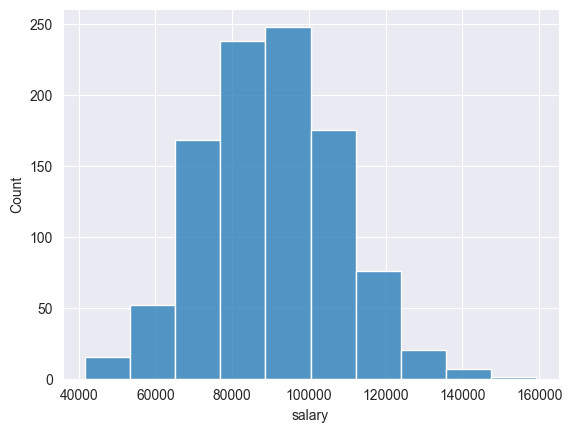

In [41]:
sns.histplot(data=df_s,x='salary',bins=10)

<Axes: xlabel='salary', ylabel='Count'>

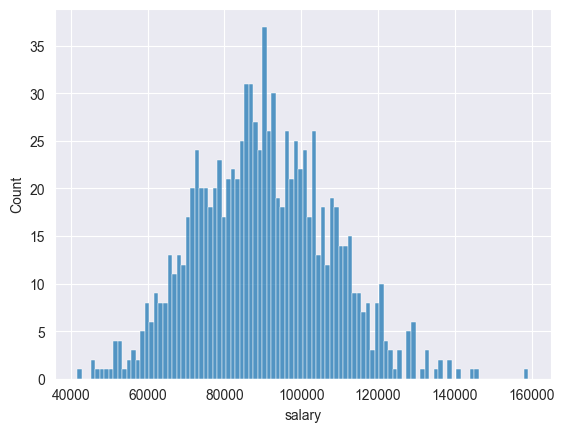

In [42]:
sns.histplot(data=df_s,x='salary',bins=100)

### Adding in a grid and styles

You can reset to a different default style: one of {darkgrid, whitegrid, dark, white, ticks}.

In a later notebook and lecture we will cover custom styling in a lot more detail.

<Axes: xlabel='salary', ylabel='Count'>

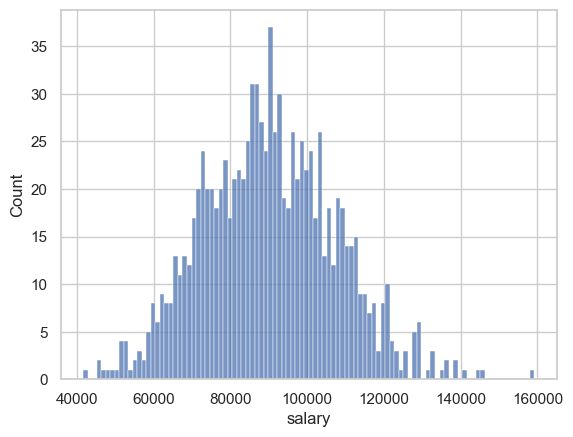

In [45]:
sns.set(style='whitegrid')
sns.histplot(data=df_s,x='salary',bins=100)

### Adding in keywords from matplotlib

Seaborn plots can accept keyword arguments directly from the matplotlib code that seaborn uses. Keep in mind, not every seaborn plot can accept all matplotlib arguments, but the main styling parameters we've discussed are available.

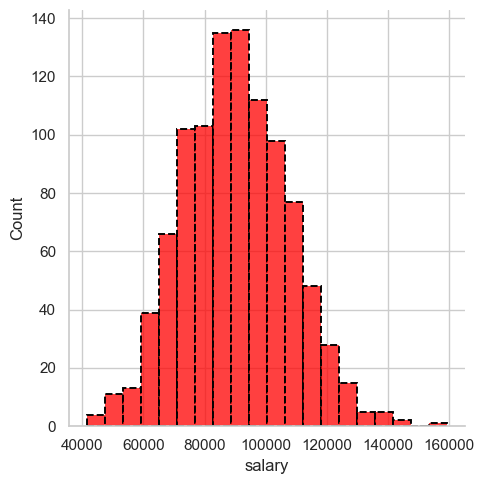

In [46]:
sns.displot(data=df_s,x='salary',bins=20,kde=False,
            color='red',edgecolor='black',lw=4,ls='--')

### Categorical Plots - Statistical Estimation within Categories

Often we have **categorical** data, meaning the data is in distinct groupings, such as Countries or Companies. There is no country value "between" USA and France and there is no company value "between" Google and Apple, unlike continuous data where we know values can exist between data points, such as age or price.

To begin with categorical plots, we'll focus on statistical estimation within categories. Basically this means we will visually report back some statistic (such as mean or count) in a plot. We already know how to get this data with pandas, but often its easier to understand the data if we plot this.

<Axes: xlabel='division', ylabel='count'>

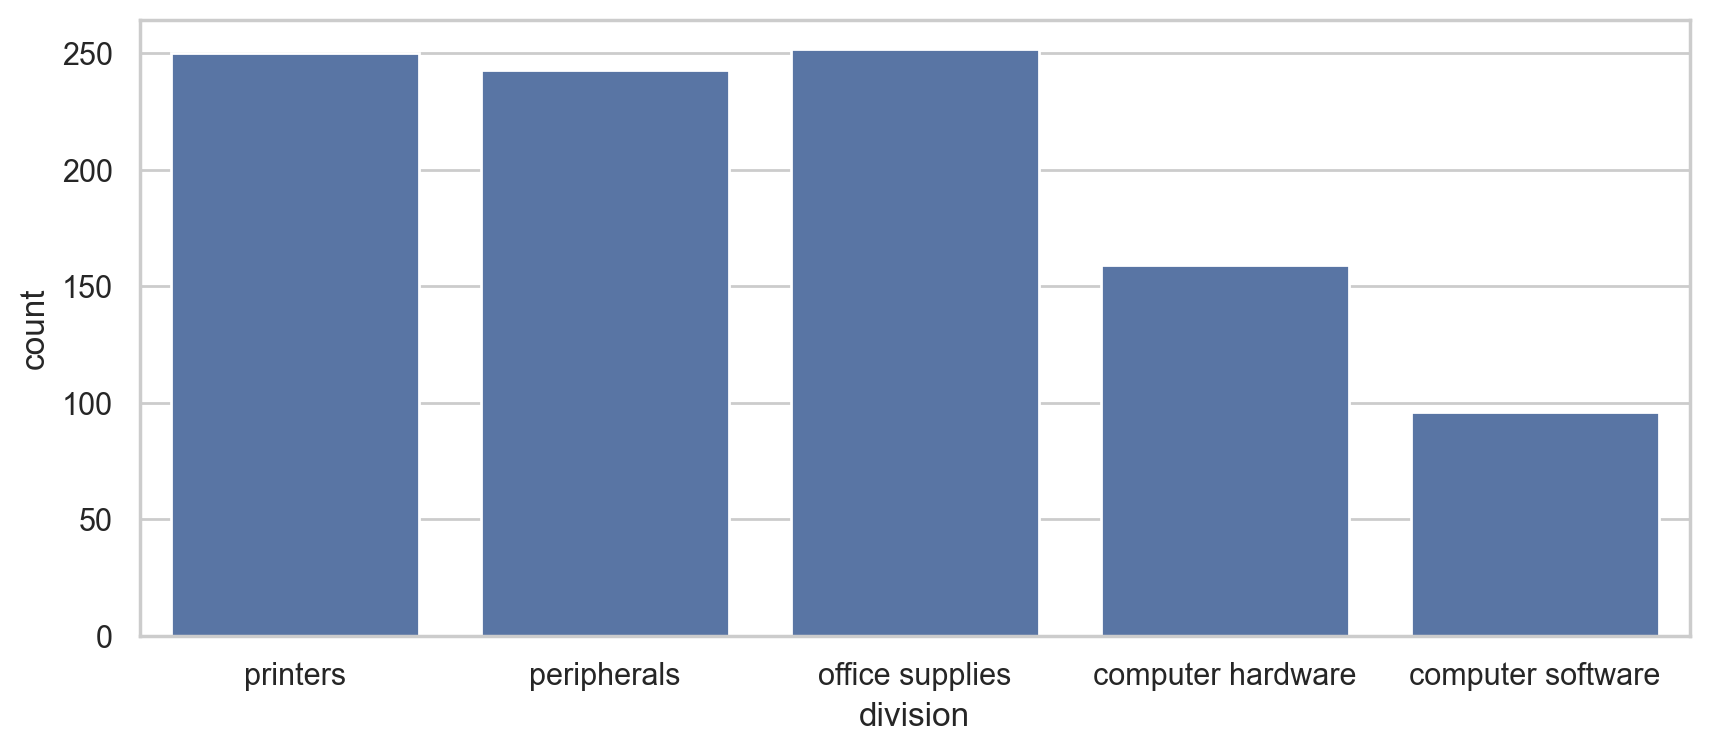

In [47]:
plt.figure(figsize=(10,4),dpi=200)
sns.countplot(x='division',data=df_s)

<Axes: xlabel='level of education', ylabel='count'>

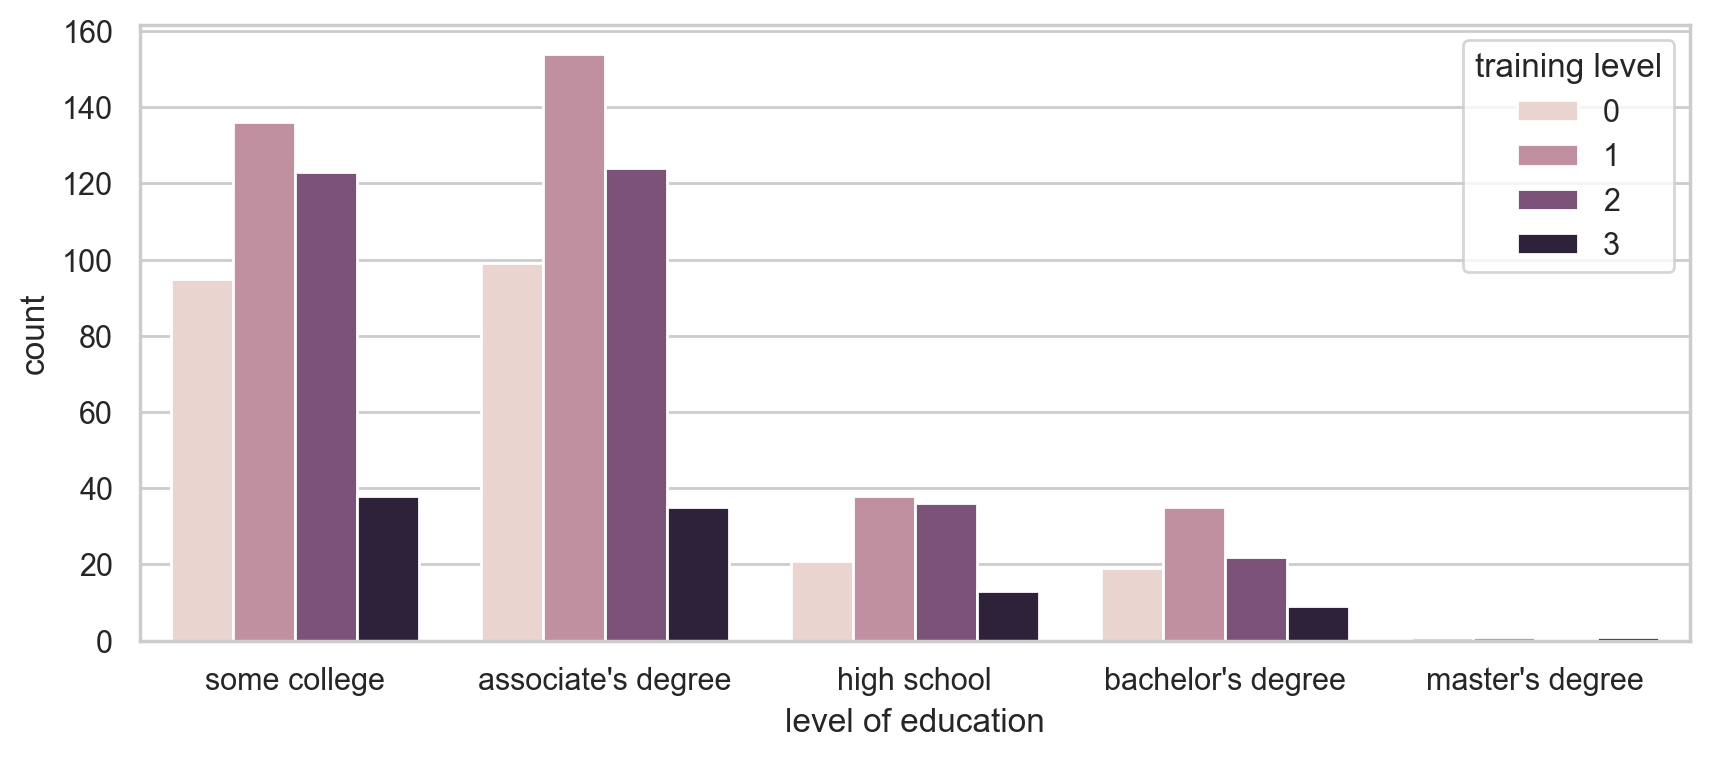

In [49]:
plt.figure(figsize=(10,4),dpi=200)
sns.countplot(x='level of education',data=df_s,hue='training level')

**NOTE: You can always edit the palette to your liking to any matplotlib [colormap](https://matplotlib.org/3.1.1/gallery/color/colormap_reference.html)**

<Axes: xlabel='level of education', ylabel='count'>

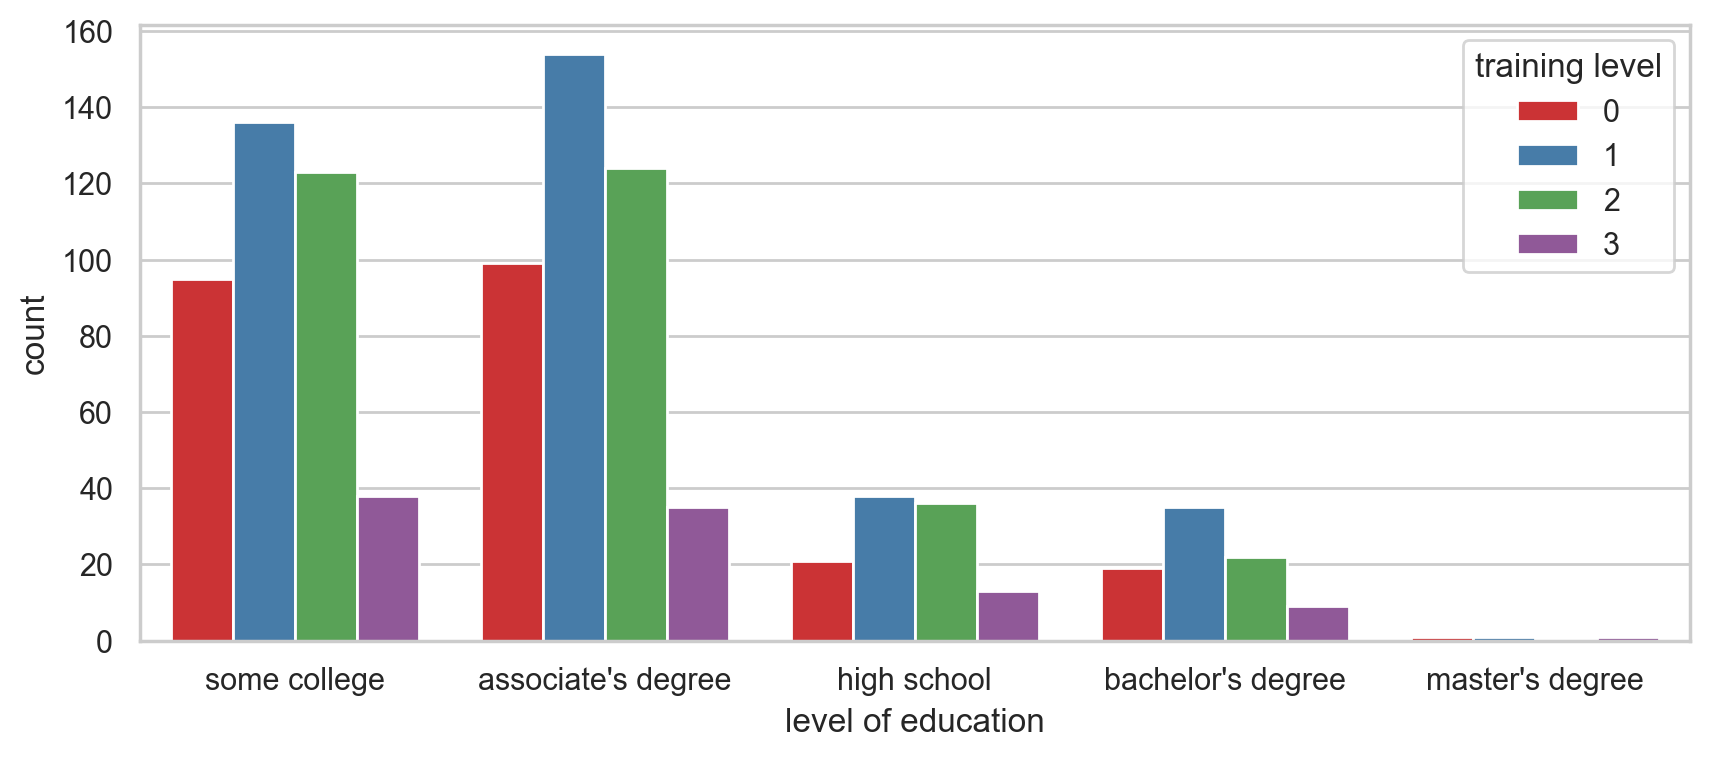

In [50]:
plt.figure(figsize=(10,4),dpi=200)
sns.countplot(x='level of education',data=df_s,hue='training level',palette='Set1')

<Axes: xlabel='level of education', ylabel='count'>

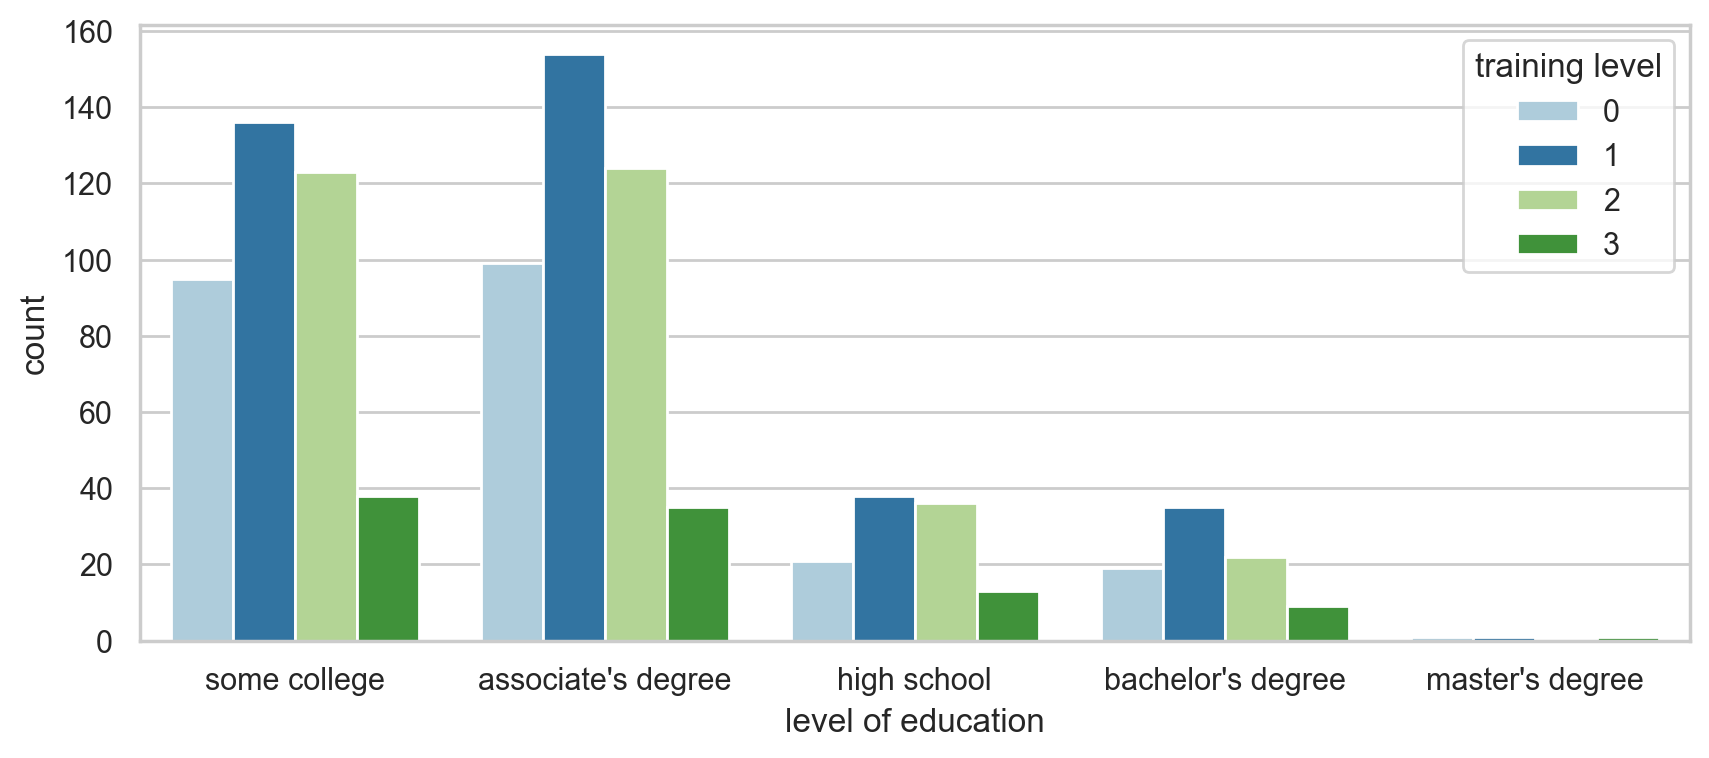

In [51]:
plt.figure(figsize=(10,4),dpi=200)
# Paired would be a good choice if there was a distinct jump from 0 and 1 to 2 and 3
sns.countplot(x='level of education',data=df_s,hue='training level',palette='Paired')

#### barplot()

So far we've seen the y axis default to a count (similar to a .groupby(x_axis).count() call in pandas). We can expand our visualizations by specifying a specific continuous feature for the y-axis. Keep in mind, you should be careful with these plots, as they may imply a relationship continuity along the y axis where there is none.

<Axes: xlabel='level of education', ylabel='salary'>

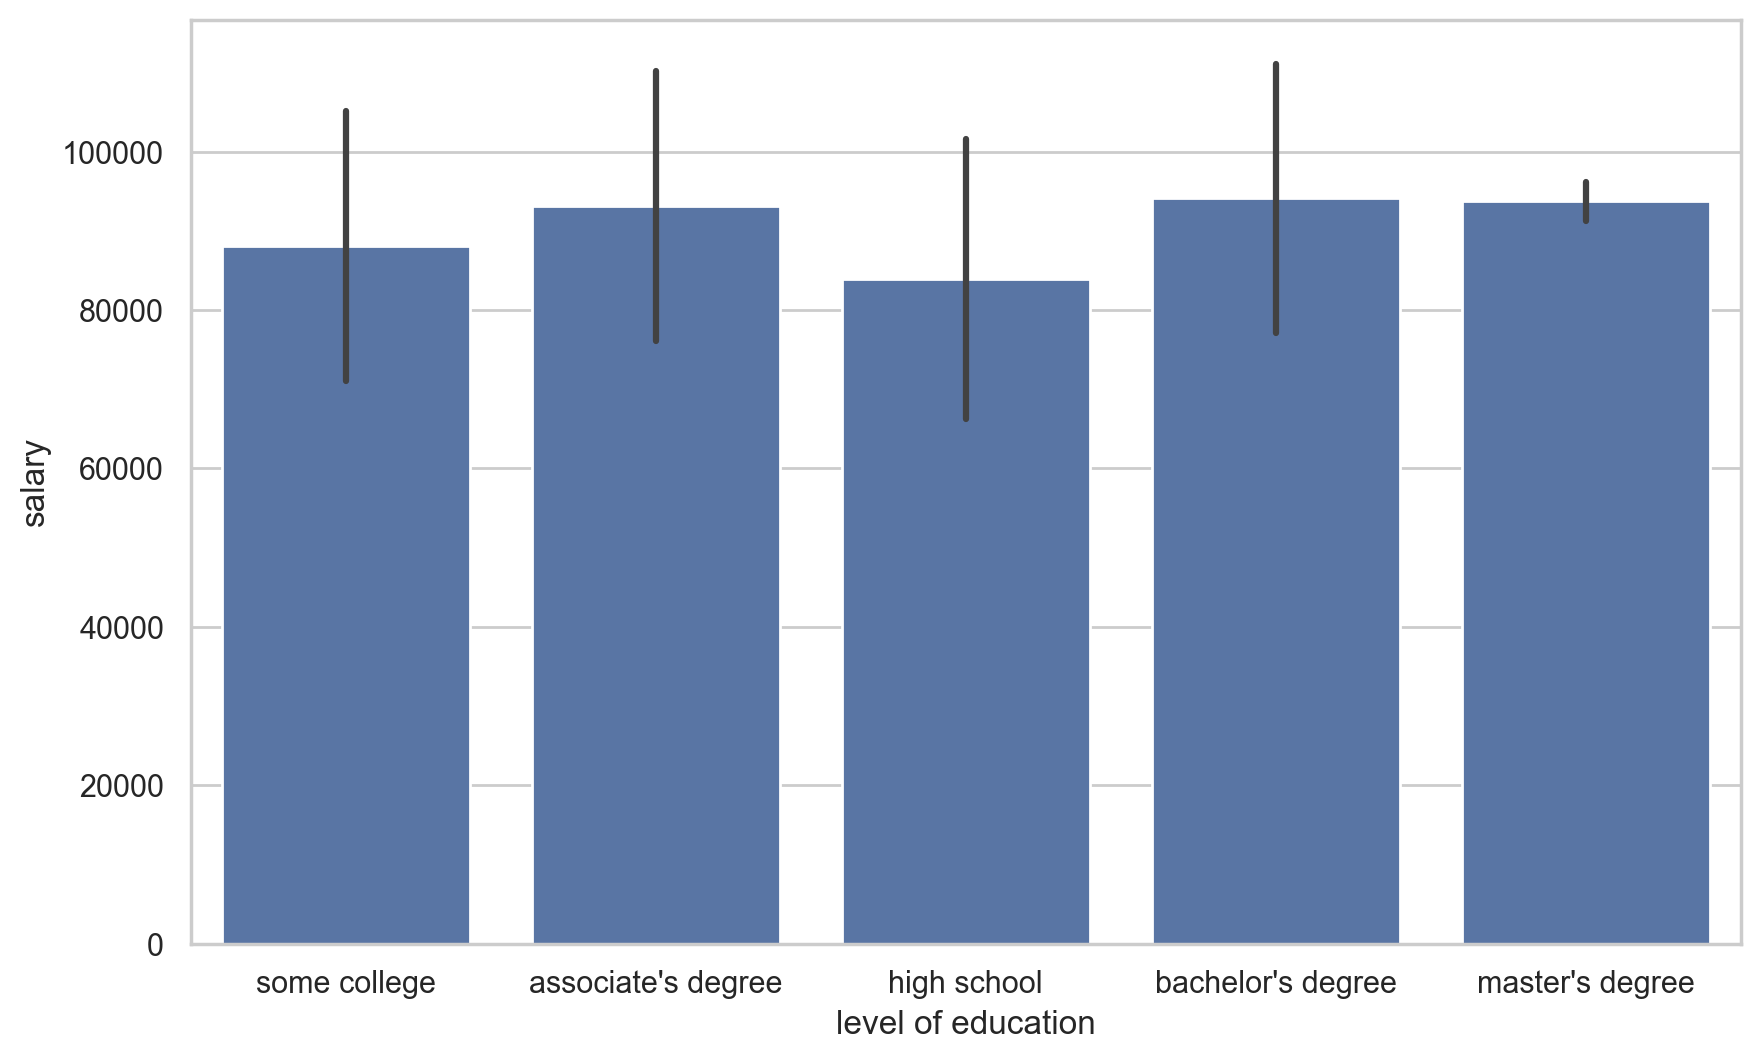

In [55]:
plt.figure(figsize=(10,6),dpi=200)
# By default barplot() will show the mean
# Information on the black bar: https://stackoverflow.com/questions/58362473/what-does-black-lines-on-a-seaborn-barplot-mean
sns.barplot(x='level of education',y='salary',data=df_s,estimator=np.mean, errorbar='sd')

| Parametre                | Açıklama                                                                              |
| ------------------------ | ------------------------------------------------------------------------------------- |
| `x='level of education'` | X ekseni → eğitim seviyesi (kategorik)                                                |
| `y='salary'`             | Y ekseni → maaş değeri (sayısal)                                                      |
| `data=df_s`              | Kullanılan veri kümesi                                                                |
| `estimator=np.mean`      | Her kategori için ortalama maaşı hesaplar (varsayılan zaten `np.mean`)                |
| `errorbar='sd'`          | Hata çubuklarını (black line) **standart sapma (standard deviation)** olarak gösterir |


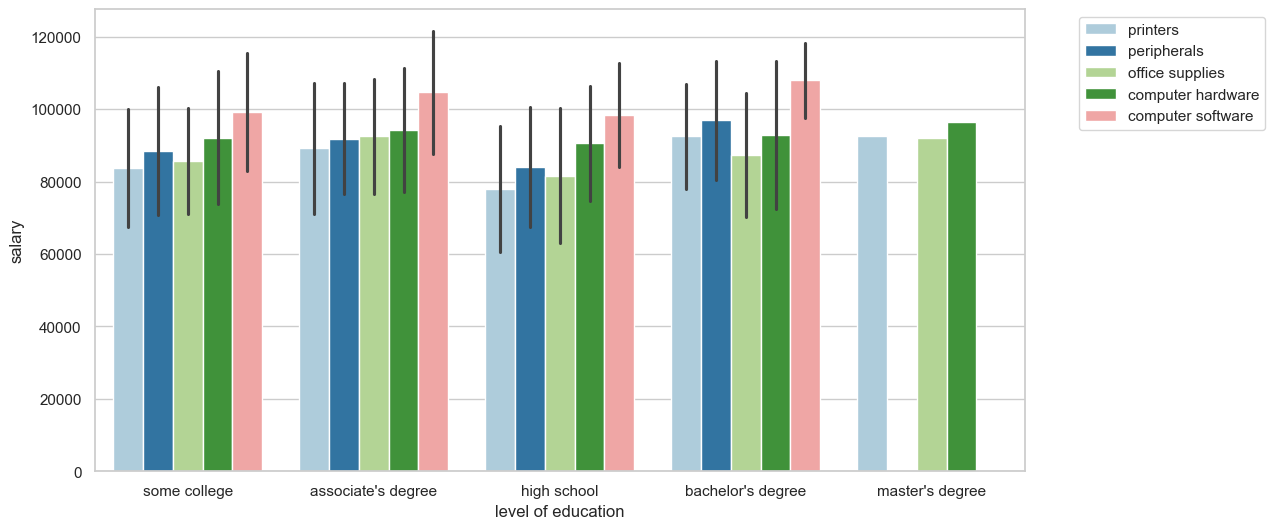

In [59]:
plt.figure(figsize=(12,6))
sns.barplot(x='level of education',y='salary',data=df_s,estimator=np.mean,errorbar='sd',hue='division',palette='Paired')

plt.legend(bbox_to_anchor=(1.05, 1))

### Categorical Plots - Distribution within Categories

So far we've seen how to apply a statistical estimation (like mean or count) to categories and compare them to one another. Let's now explore how to visualize the distribution within categories. We already know about distplot() which allows to view the distribution of a single feature, now we will break down that same distribution per category.

In [62]:
df_p = pd.read_csv("./../data/StudentsPerformance.csv")
df_p.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Boxplot

As described in the video, a boxplot display distribution through the use of quartiles and an IQR for outliers.

<Axes: xlabel='parental level of education', ylabel='math score'>

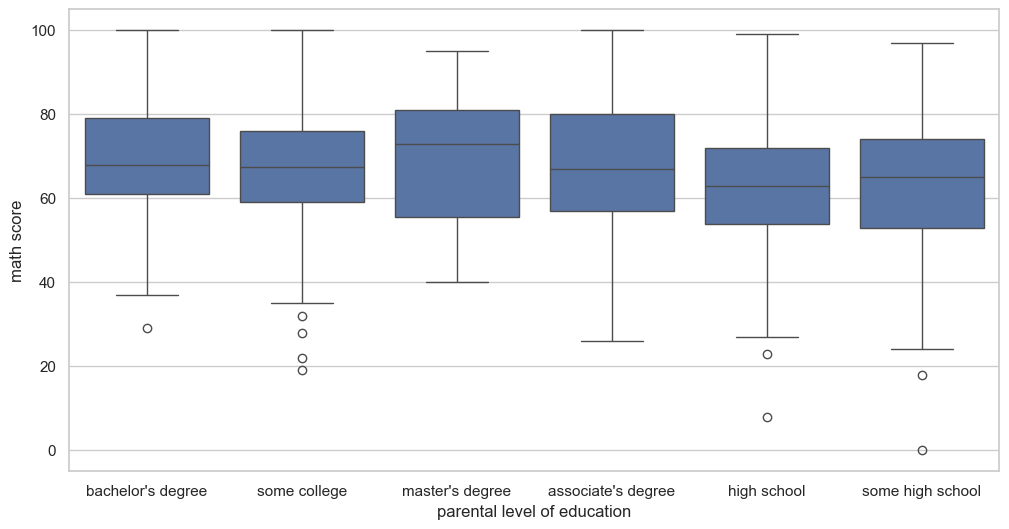

In [63]:
plt.figure(figsize=(12,6))
sns.boxplot(x='parental level of education',y='math score',data=df_p)

##### Adding hue for further segmentation

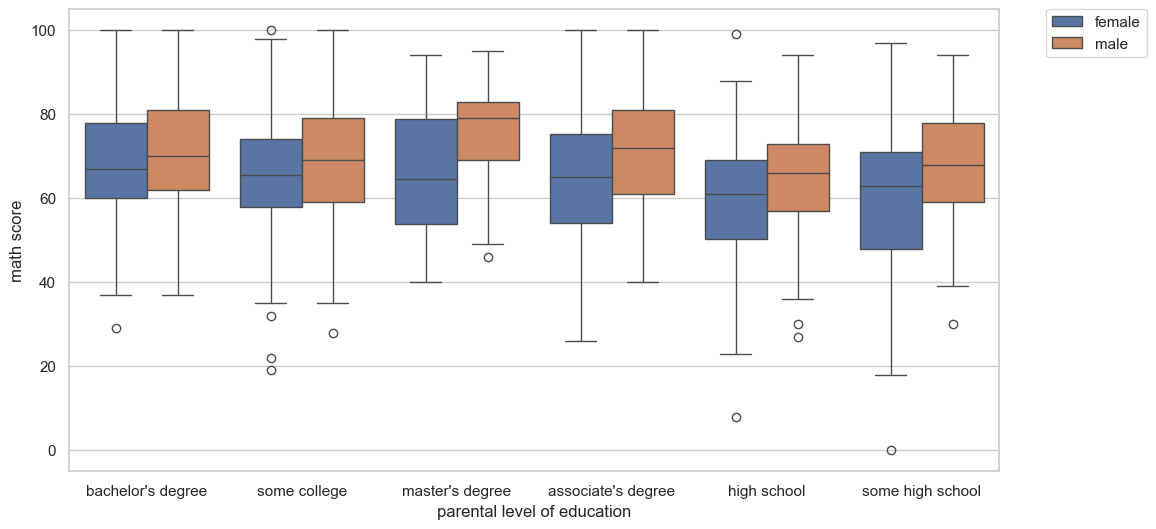

In [64]:
plt.figure(figsize=(12,6))
sns.boxplot(x='parental level of education',y='math score',data=df_p,hue='gender')

# Optional move the legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

### Boxplot Styling Parameters

#### Orientation

<Axes: xlabel='math score', ylabel='parental level of education'>

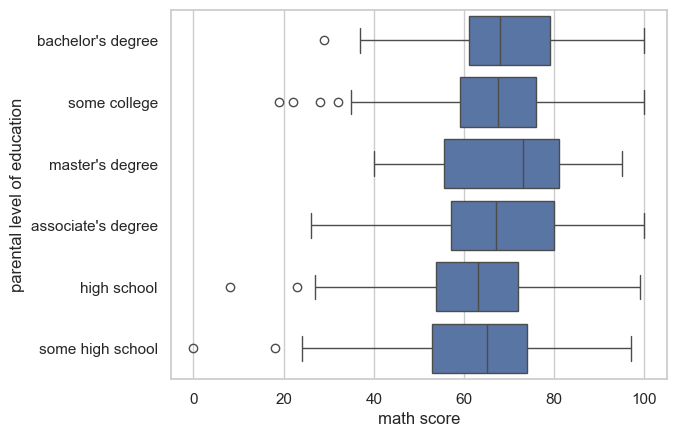

In [66]:
# NOTICE HOW WE HAVE TO SWITCH X AND Y FOR THE ORIENTATION TO MAKE SENSE!
sns.boxplot(x='math score',y='parental level of education',data=df_p,orient='h')

<Axes: xlabel='parental level of education', ylabel='math score'>

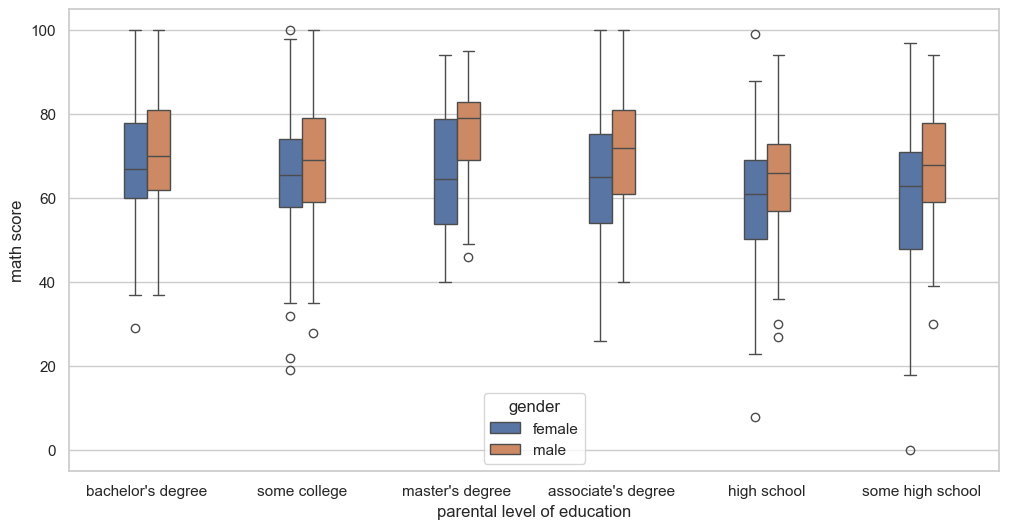

In [68]:
# WIDTH

plt.figure(figsize=(12,6))
sns.boxplot(x='parental level of education',y='math score',data=df_p,hue='gender',width=0.3)

### Violinplot

A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

<Axes: xlabel='parental level of education', ylabel='math score'>

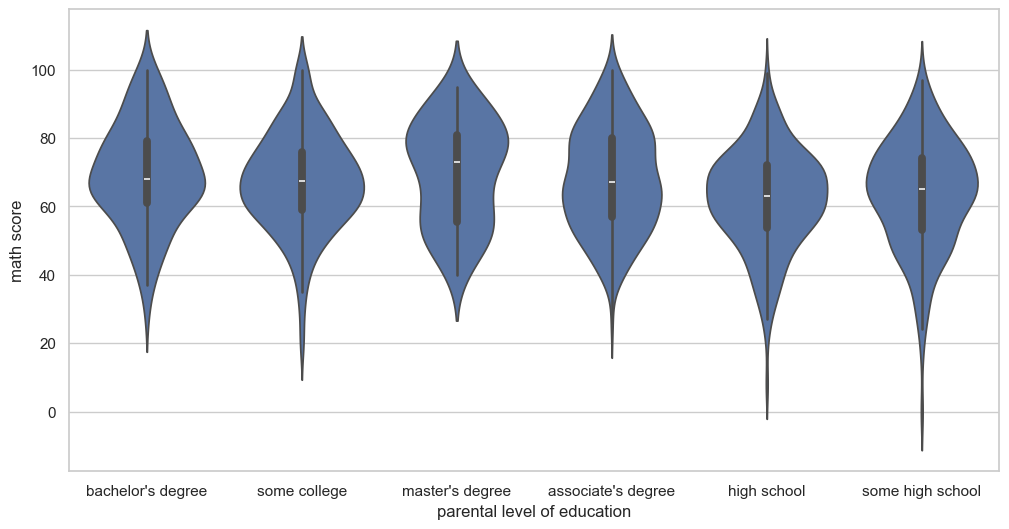

In [69]:
plt.figure(figsize=(12,6))
sns.violinplot(x='parental level of education',y='math score',data=df_p)

<Axes: xlabel='parental level of education', ylabel='math score'>

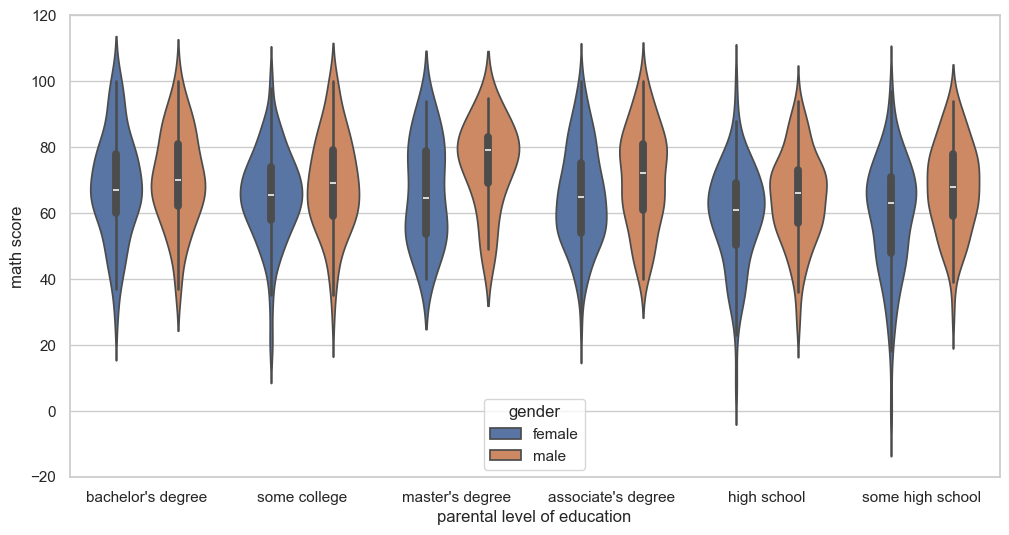

In [70]:
plt.figure(figsize=(12,6))
sns.violinplot(x='parental level of education',y='math score',data=df_p,hue='gender')

### Violinplot Parameters

#### split
When using hue nesting with a variable that takes two levels, setting split to True will draw half of a violin for each level. This can make it easier to directly compare the distributions.

<Axes: xlabel='parental level of education', ylabel='math score'>

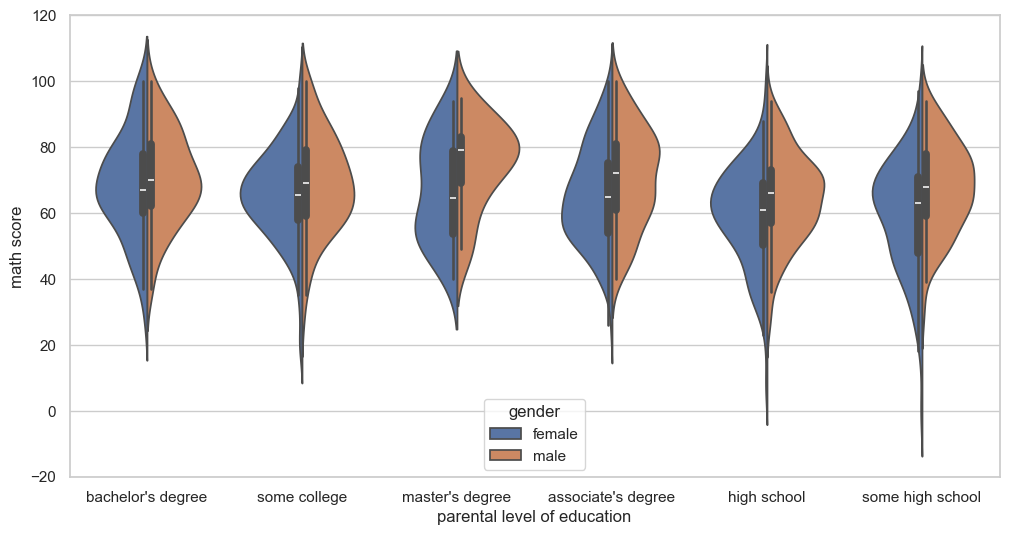

In [71]:
plt.figure(figsize=(12,6))
sns.violinplot(x='parental level of education',y='math score',data=df_p,hue='gender',split=True)

#### inner

Representation of the datapoints in the violin interior. If box, draw a miniature boxplot. If quartiles, draw the quartiles of the distribution. If point or stick, show each underlying datapoint. Using None will draw unadorned violins.

<Axes: xlabel='parental level of education', ylabel='math score'>

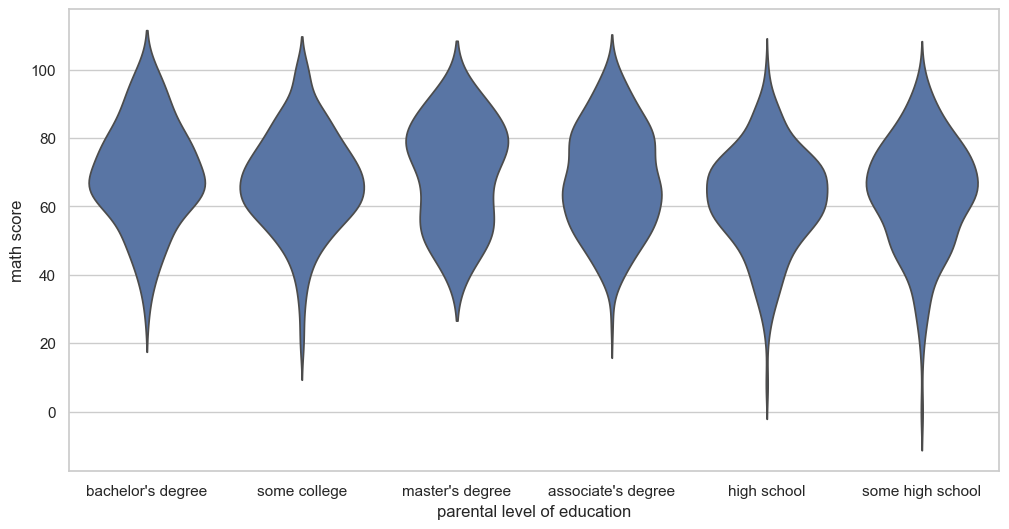

In [72]:
plt.figure(figsize=(12,6))
sns.violinplot(x='parental level of education',y='math score',data=df_p,inner=None)

<Axes: xlabel='parental level of education', ylabel='math score'>

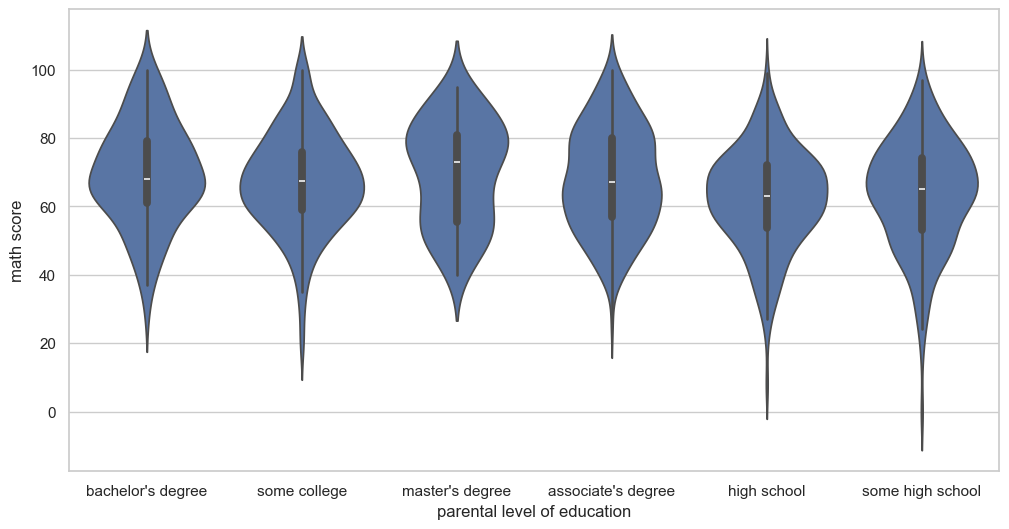

In [73]:
plt.figure(figsize=(12,6))
sns.violinplot(x='parental level of education',y='math score',data=df_p,inner='box')

<Axes: xlabel='parental level of education', ylabel='math score'>

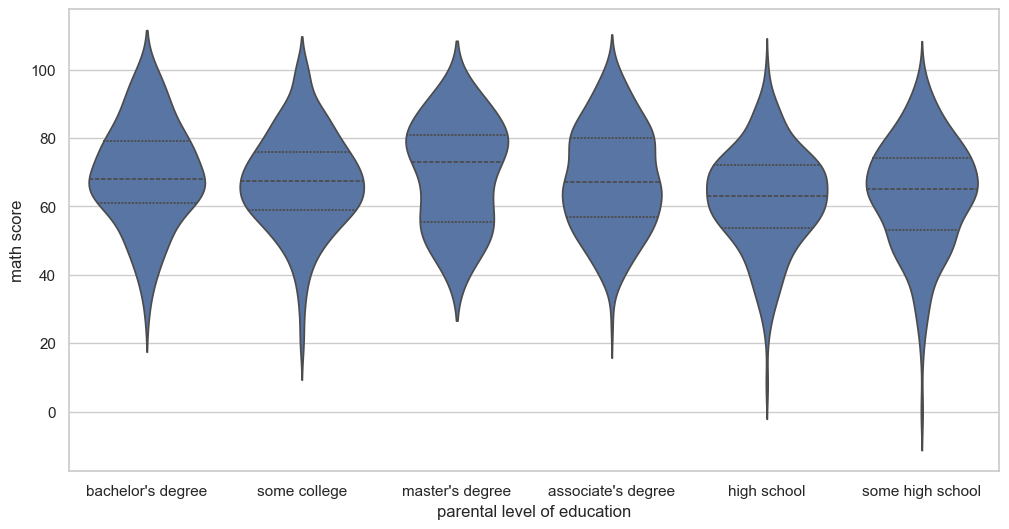

In [74]:
plt.figure(figsize=(12,6))
sns.violinplot(x='parental level of education',y='math score',data=df_p,inner='quartile')

<Axes: xlabel='parental level of education', ylabel='math score'>

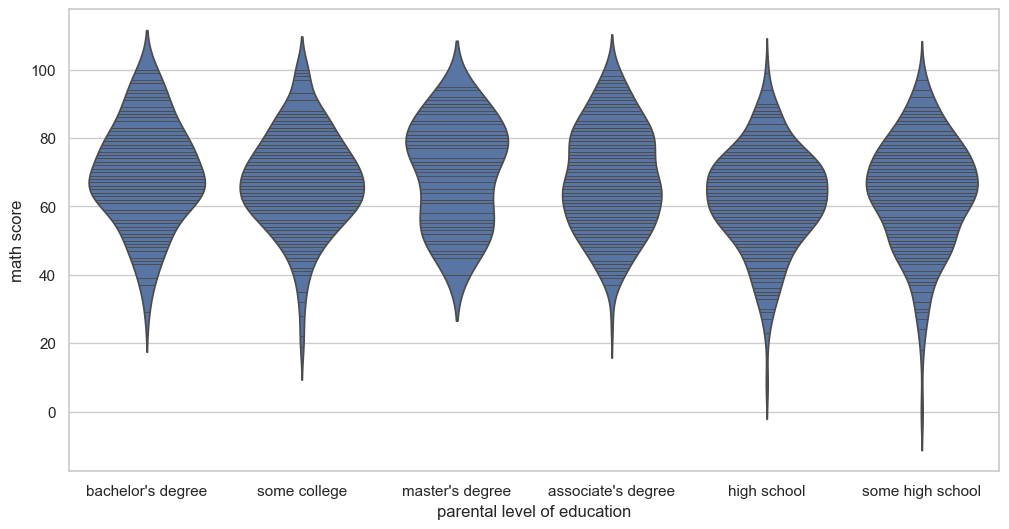

In [75]:
plt.figure(figsize=(12,6))
sns.violinplot(x='parental level of education',y='math score',data=df_p,inner='stick')

#### orientation

<Axes: xlabel='math score', ylabel='parental level of education'>

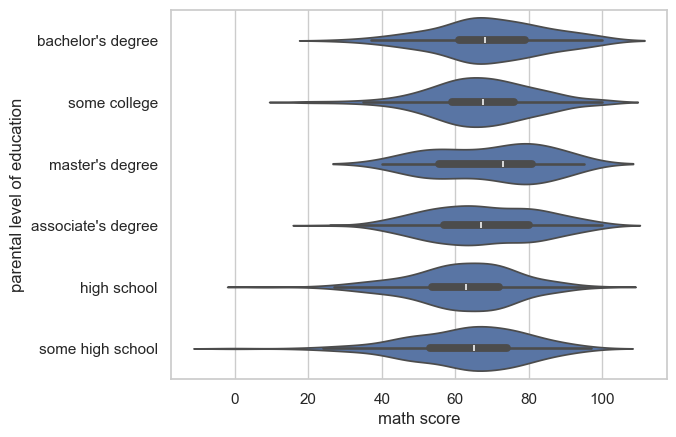

In [76]:
# Simply switch the continuous variable to y and the categorical to x
sns.violinplot(x='math score',y='parental level of education',data=df_p)

#### bandwidth

Similar to bandwidth argument for kdeplot

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_15617/1067043621.py:2: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.1`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(x='parental level of education',y='math score',data=df_p,bw=0.1)


<Axes: xlabel='parental level of education', ylabel='math score'>

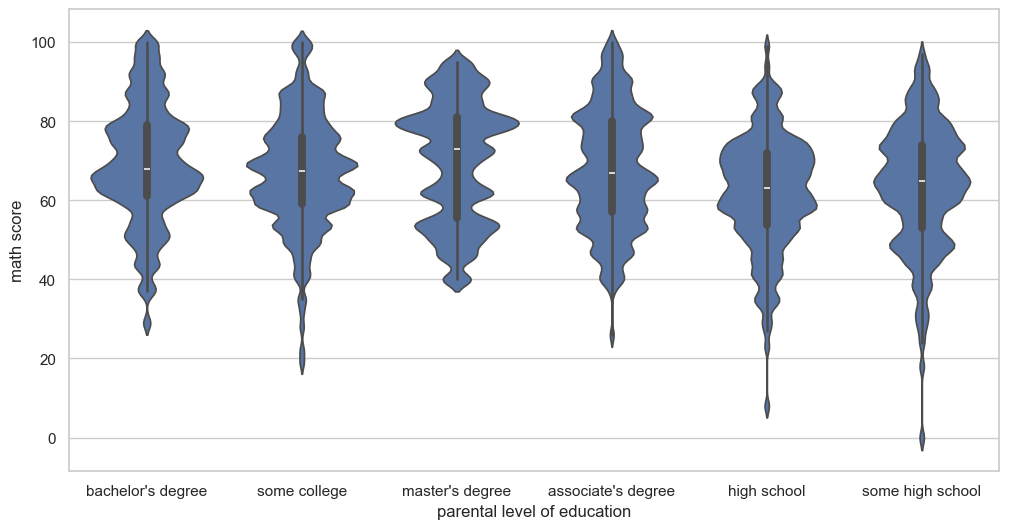

In [77]:
plt.figure(figsize=(12,6))
sns.violinplot(x='parental level of education',y='math score',data=df_p,bw=0.1)

# Advanced Plots

We can use a boxenplot and swarmplot to achieve the same effect as the boxplot and violinplot, but with slightly more information included. Be careful when using these plots, as they often require you to educate the viewer with how the plot is actually constructed. Only use these if you are sure your audience will understand the visualization.

#### SwarmPlot

<Axes: xlabel='math score'>

/Users/zehra/PycharmProjects/data-analytics-notes/.venv/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


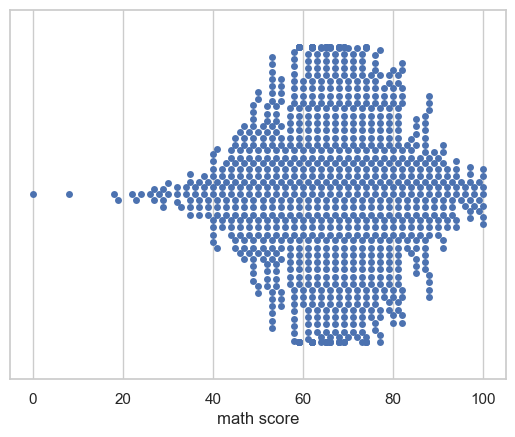

In [78]:
sns.swarmplot(x='math score',data=df_p)

<Axes: xlabel='math score'>

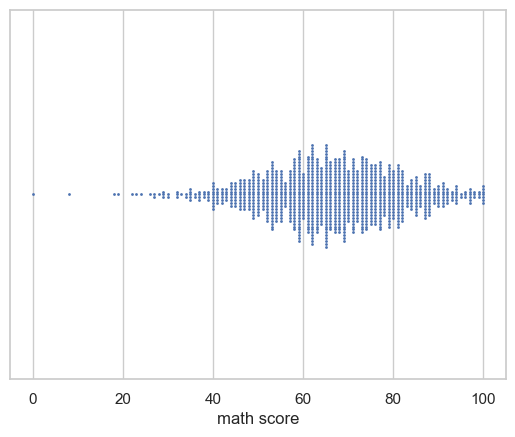

In [79]:
sns.swarmplot(x='math score',data=df_p,size=2)

<Axes: xlabel='math score', ylabel='race/ethnicity'>

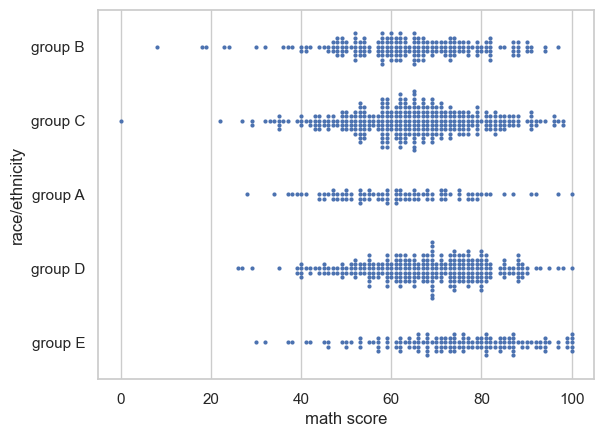

In [80]:
sns.swarmplot(x='math score',y='race/ethnicity',data=df_p,size=3)

<Axes: xlabel='race/ethnicity', ylabel='math score'>

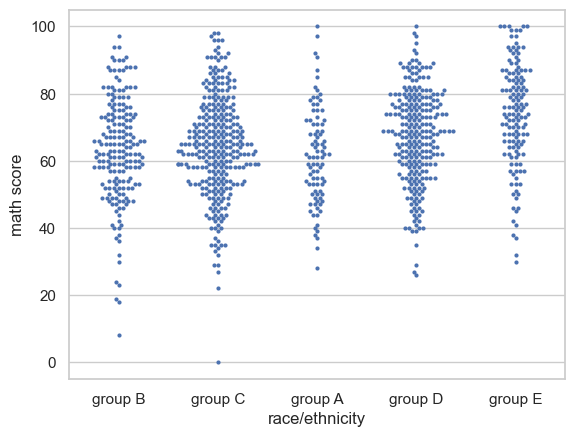

In [81]:
sns.swarmplot(x='race/ethnicity',y='math score',data=df_p,size=3)

<Axes: xlabel='race/ethnicity', ylabel='math score'>

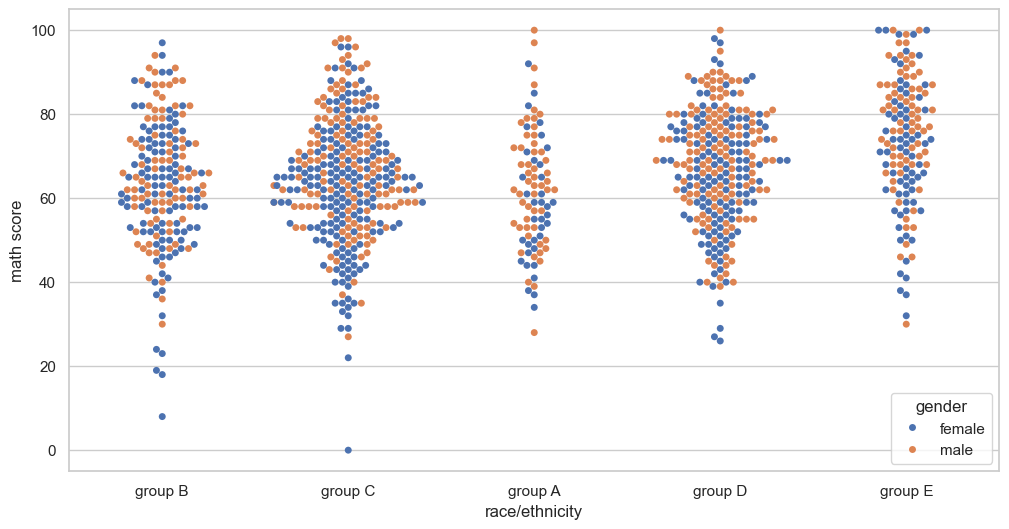

In [82]:
plt.figure(figsize=(12,6))
sns.swarmplot(x='race/ethnicity',y='math score',data=df_p,hue='gender')

<Axes: xlabel='race/ethnicity', ylabel='math score'>

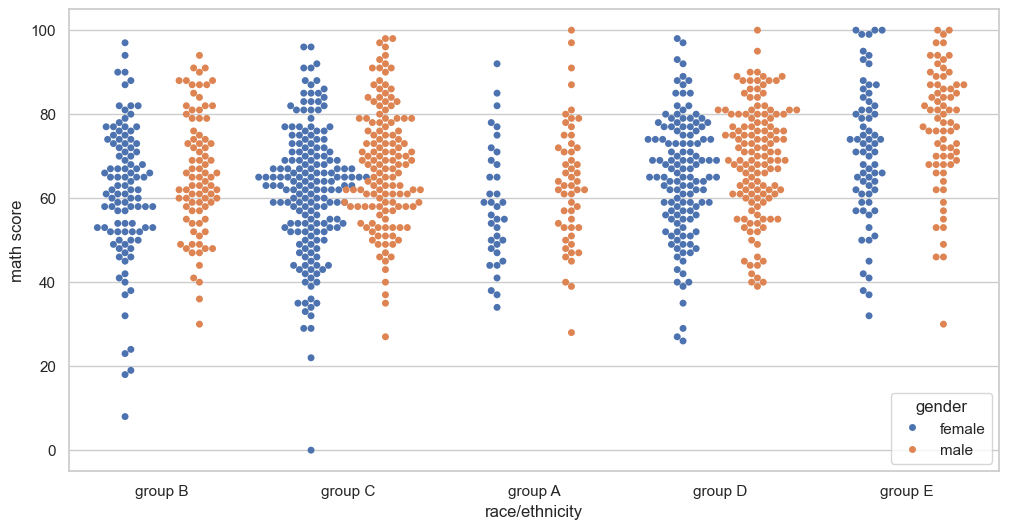

In [83]:
plt.figure(figsize=(12,6))
sns.swarmplot(x='race/ethnicity',y='math score',data=df_p,hue='gender',dodge=True)

### boxenplot (letter-value plot)

Official Paper on this plot: https://vita.had.co.nz/papers/letter-value-plot.html

This style of plot was originally named a “letter value” plot because it shows a large number of quantiles that are defined as “letter values”. It is similar to a box plot in plotting a nonparametric representation of a distribution in which all features correspond to actual observations. By plotting more quantiles, it provides more information about the shape of the distribution, particularly in the tails.

<Axes: xlabel='math score', ylabel='race/ethnicity'>

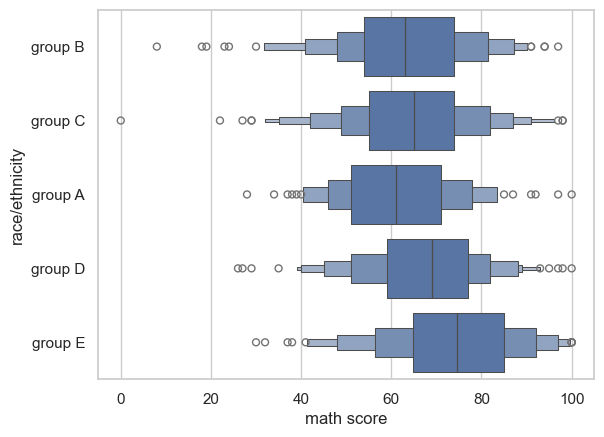

In [84]:
sns.boxenplot(x='math score',y='race/ethnicity',data=df_p)

<Axes: xlabel='race/ethnicity', ylabel='math score'>

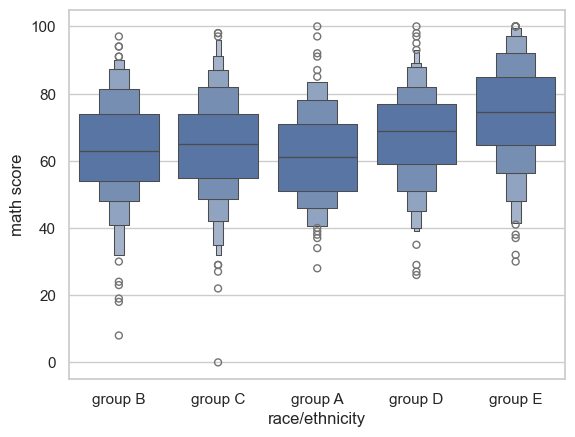

In [85]:
sns.boxenplot(x='race/ethnicity',y='math score',data=df_p)

####  Matrix Plots

**NOTE: Make sure to watch the video lecture, not all datasets are well suited for a heatmap or clustermap.**

In [91]:
df_c = pd.read_csv('./../data/country_table.csv')
df_c.head()

,Countries,Birth rate,Mortality rate,Life expectancy,Infant mortality rate,Growth rate
0,AFRICA,32.577,7.837,63.472,44.215,24.40
1,ASIA,15.796,7.030,73.787,23.185,8.44
2,EUROPE,10.118,11.163,78.740,3.750,0.38
3,LATIN AMERICA AND THE CARIBBEAN,15.886,6.444,75.649,14.570,8.89
4,NORTHERN AMERICA,11.780,8.833,79.269,5.563,6.11


HEAT MAP

In [95]:
df_c = df_c.set_index('Countries')
df_c.head()

,Birth rate,Mortality rate,Life expectancy,Infant mortality rate,Growth rate
Countries,,,,,
AFRICA,32.577,7.837,63.472,44.215,24.40
ASIA,15.796,7.030,73.787,23.185,8.44
EUROPE,10.118,11.163,78.740,3.750,0.38
LATIN AMERICA AND THE CARIBBEAN,15.886,6.444,75.649,14.570,8.89
NORTHERN AMERICA,11.780,8.833,79.269,5.563,6.11


<Axes: ylabel='Countries'>

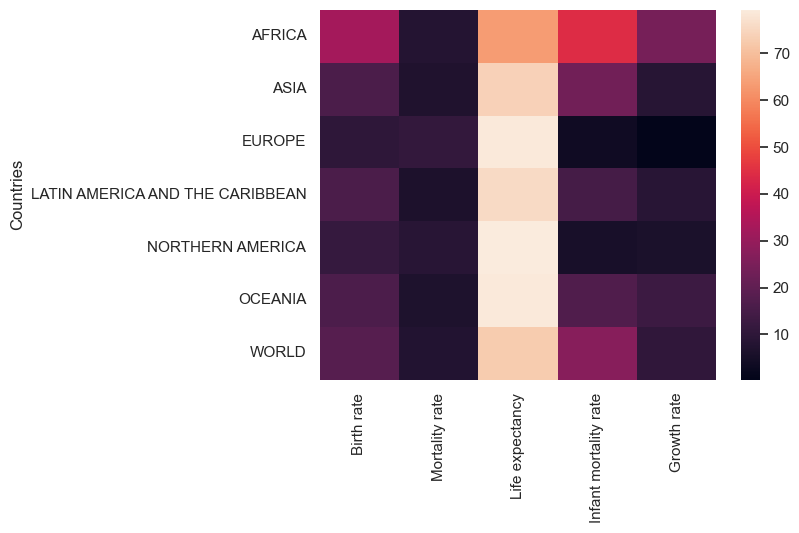

In [96]:
# Clearly shows life expectancy in different units
sns.heatmap(df_c)

In [97]:
rates = df.drop('Life expectancy',axis=1)

<Axes: ylabel='Countries'>

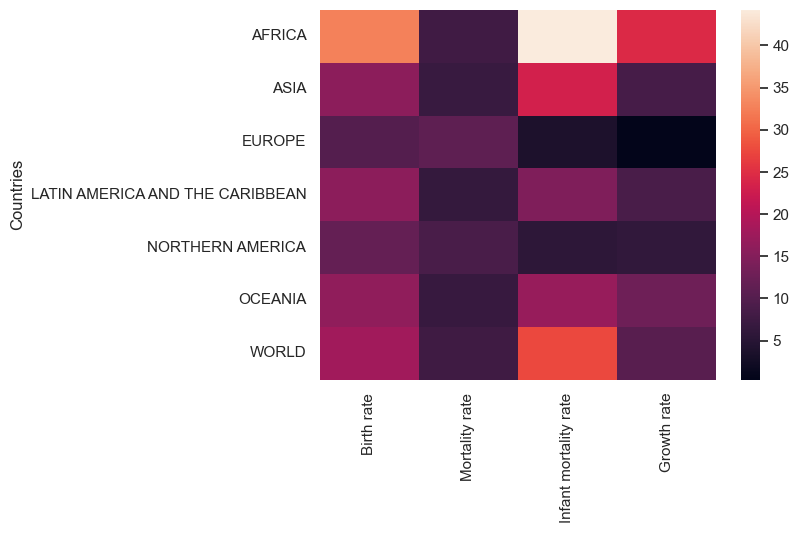

In [98]:
sns.heatmap(rates)

<Axes: ylabel='Countries'>

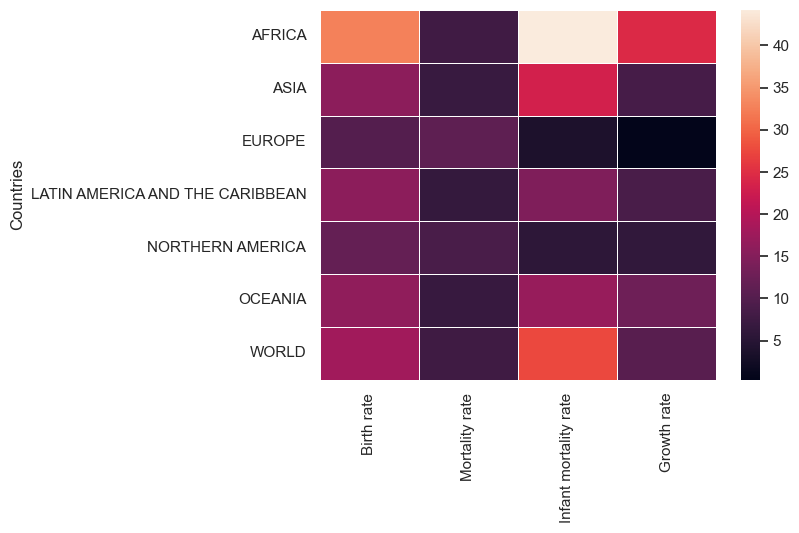

In [99]:
sns.heatmap(rates,linewidth=0.5)

<Axes: ylabel='Countries'>

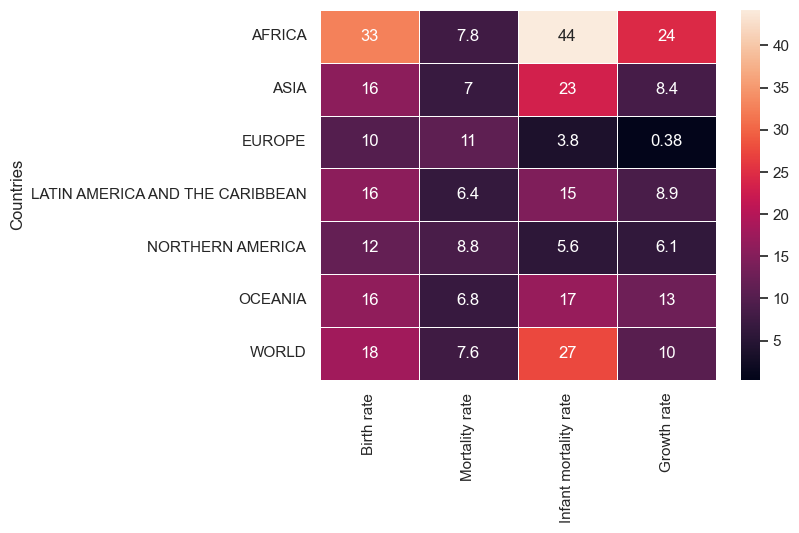

In [100]:
sns.heatmap(rates,linewidth=0.5,annot=True)

<Axes: ylabel='Countries'>

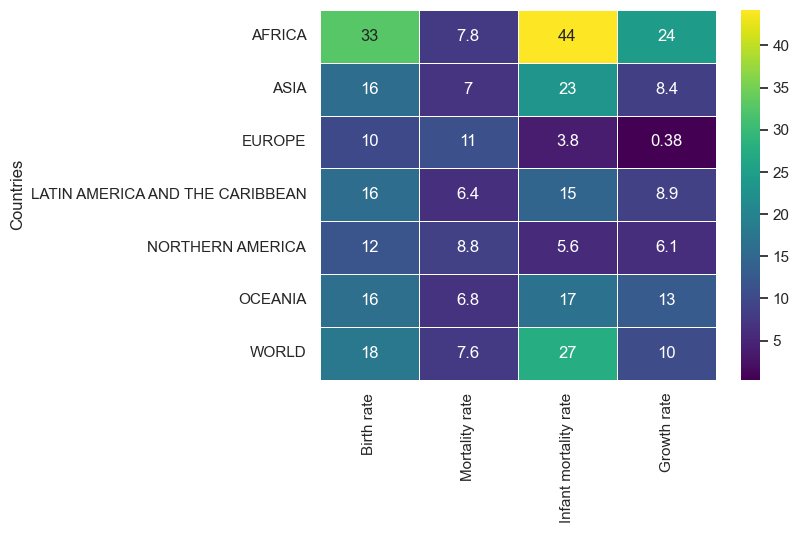

In [101]:
# Note how its not palette here
sns.heatmap(rates,linewidth=0.5,annot=True,cmap='viridis')

<Axes: ylabel='Countries'>

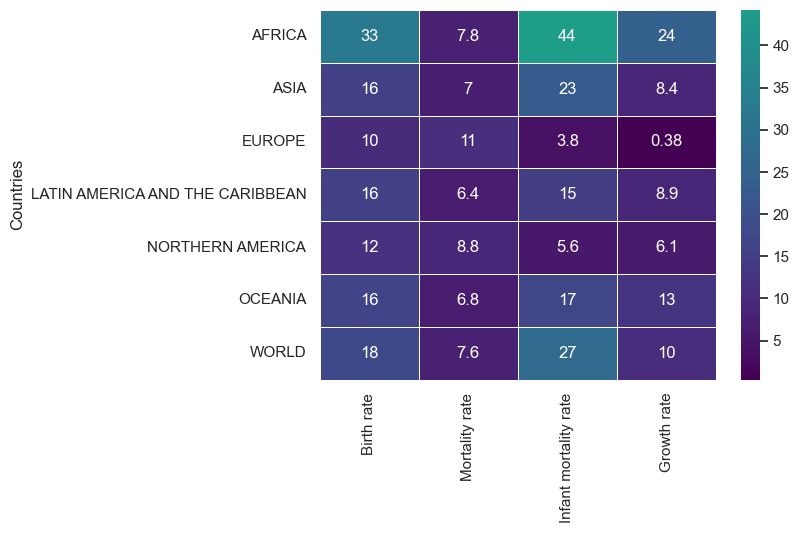

In [102]:
# Set colorbar based on value from dataset
sns.heatmap(rates,linewidth=0.5,annot=True,cmap='viridis',center=40)

<Axes: ylabel='Countries'>

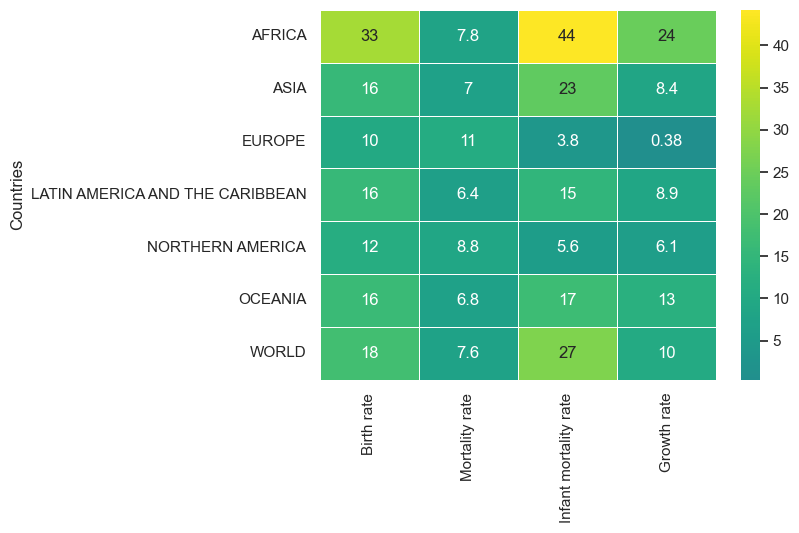

In [103]:
# Set colorbar based on value from dataset
sns.heatmap(rates,linewidth=0.5,annot=True,cmap='viridis',center=1)

#### Clustermap

Plot a matrix dataset as a hierarchically-clustered heatmap.

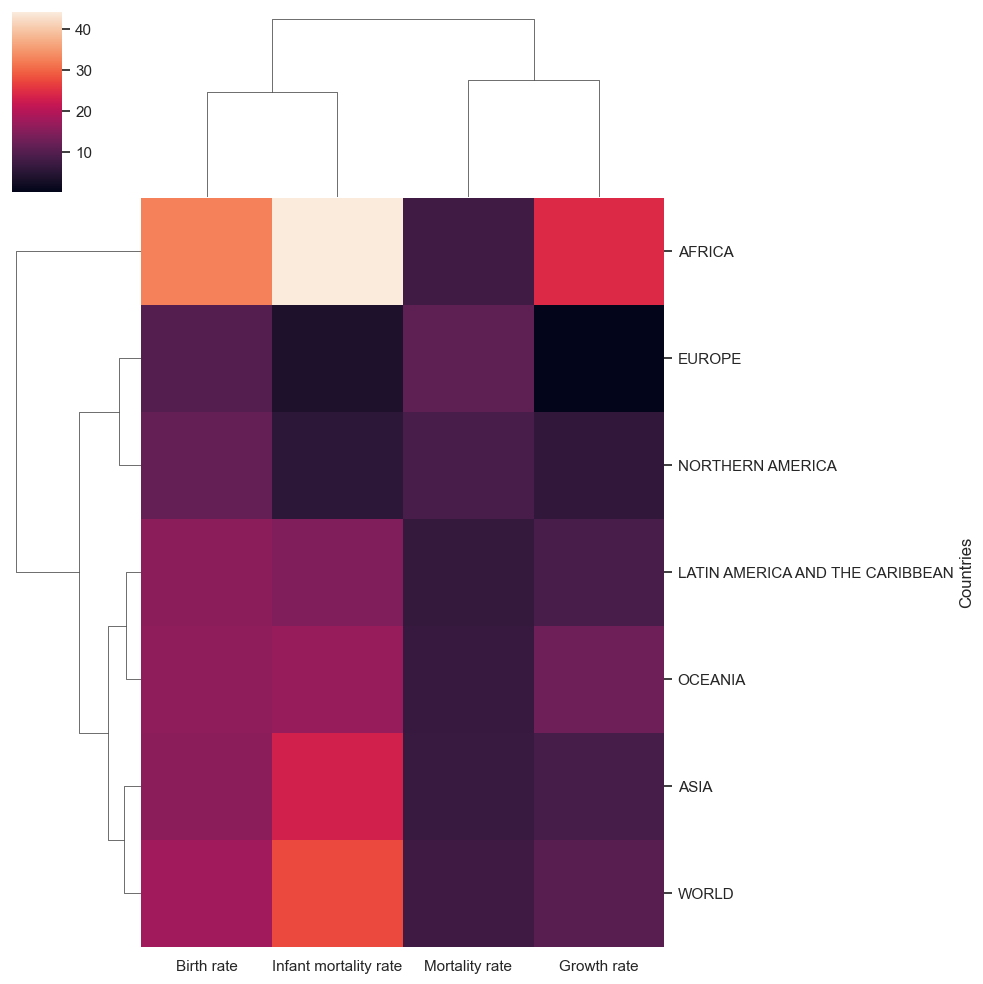

In [104]:
sns.clustermap(rates)

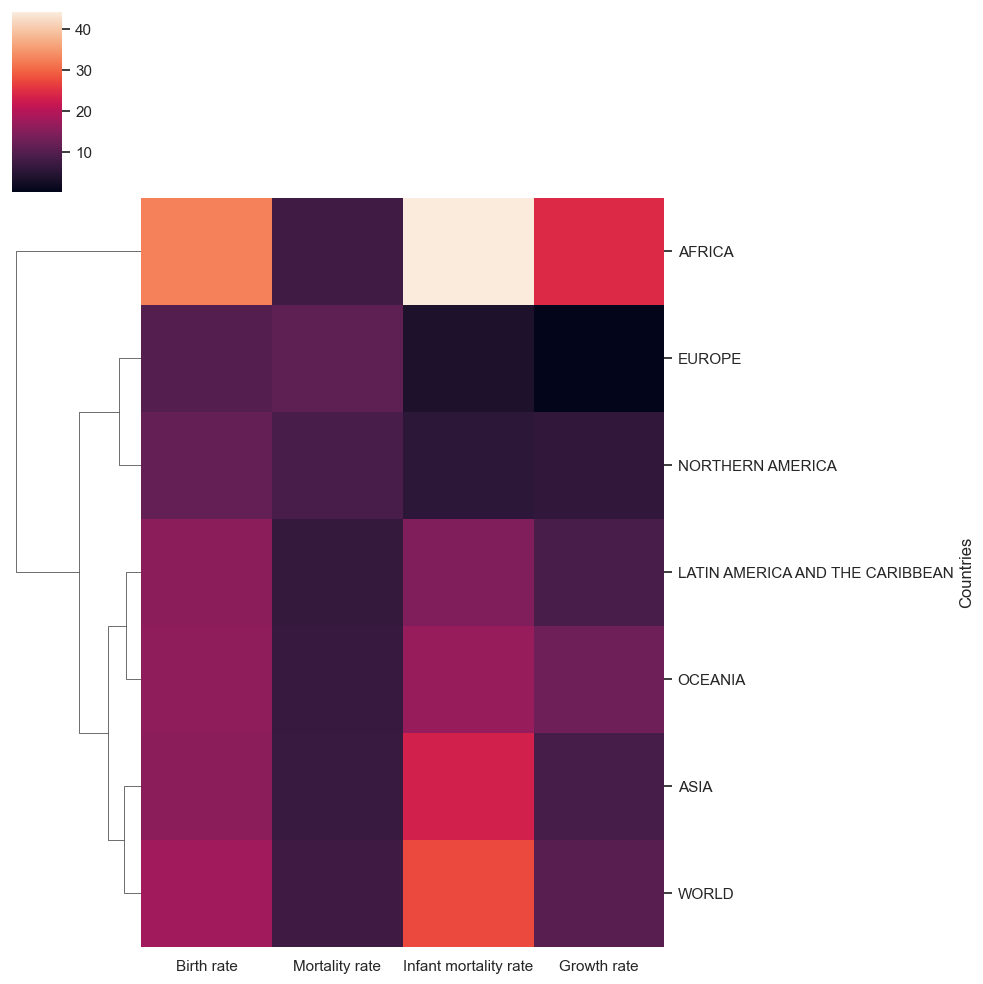

In [105]:
sns.clustermap(rates,col_cluster=False)

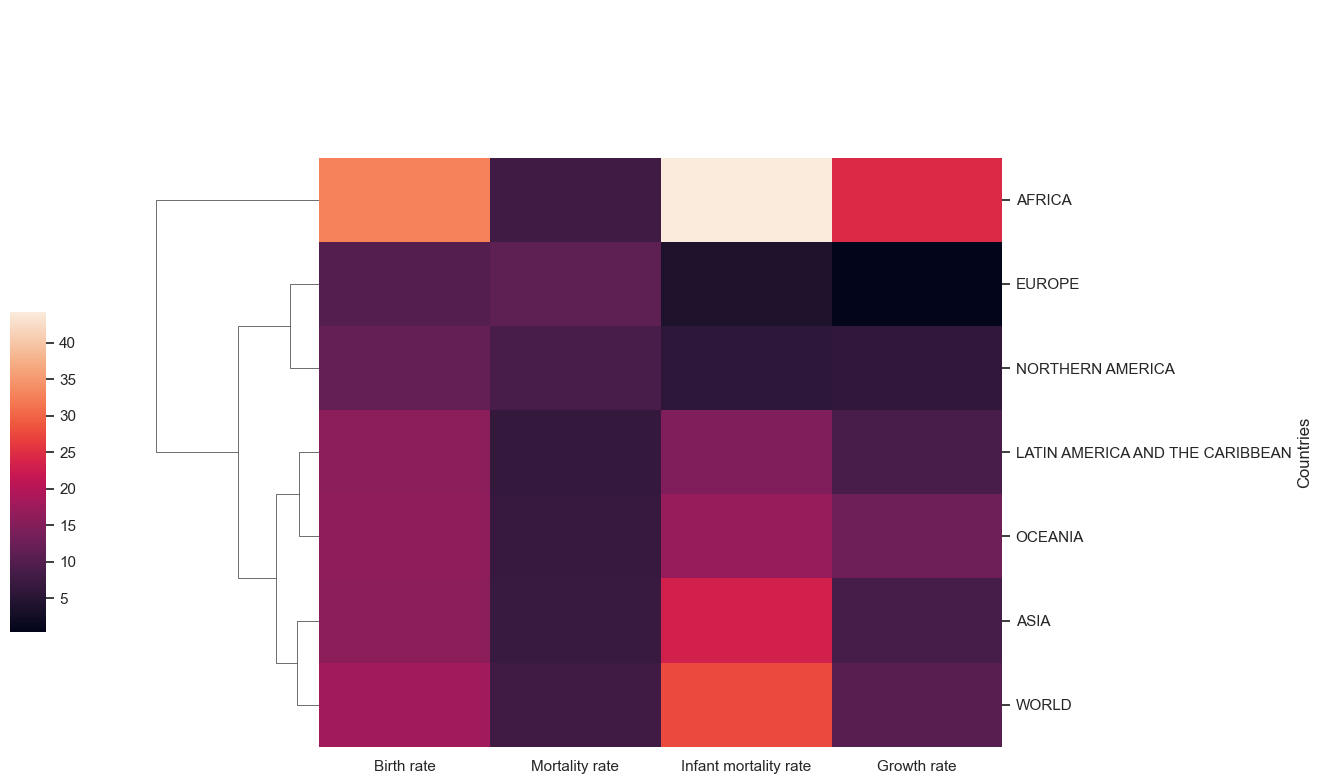

In [106]:
sns.clustermap(rates,col_cluster=False,figsize=(12,8),cbar_pos=(-0.1, .2, .03, .4))

In [110]:
rates.index.set_names('',inplace=True)
rates

,Birth rate,Mortality rate,Infant mortality rate,Growth rate
,,,,
AFRICA,32.577,7.837,44.215,24.40
ASIA,15.796,7.030,23.185,8.44
EUROPE,10.118,11.163,3.750,0.38
LATIN AMERICA AND THE CARIBBEAN,15.886,6.444,14.570,8.89
NORTHERN AMERICA,11.780,8.833,5.563,6.11
OCEANIA,16.235,6.788,16.939,12.79
WORLD,17.963,7.601,27.492,10.36


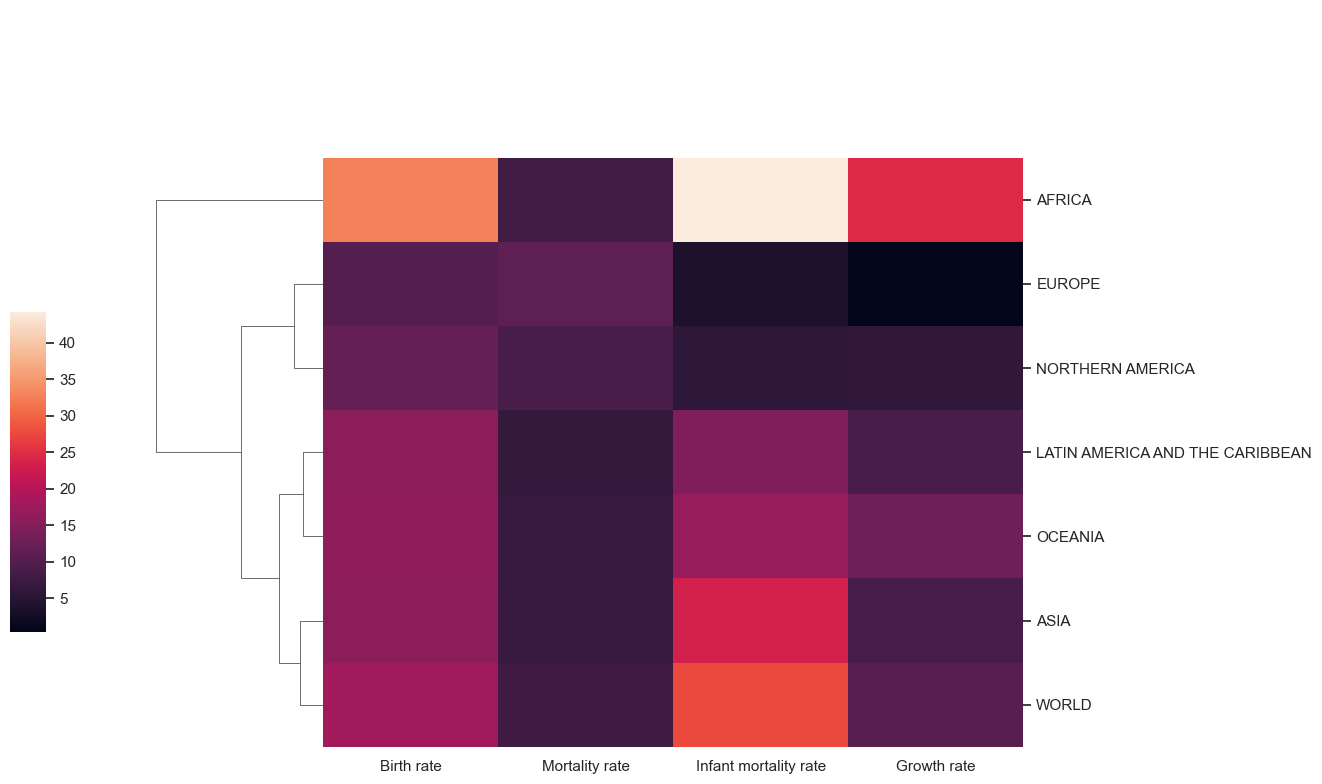

In [111]:
# Recall you can always edit the DF before seaborn
sns.clustermap(rates,col_cluster=False,figsize=(12,8),cbar_pos=(-0.1, .2, .03, .4))